# BhuvanFitter — gene-expression distribution fitting

Per-gene tools, imported from `bhuvanfitter.py` (the single source of truth).
`BhuvanFitter` supports two fit models via the same `fit()` / `hist()` interface:

- **`fit("fourparam")`** — fits a 4-parameter Gaussian to the 40-bin histogram by
  ordinary least squares and returns
  `gene, y0, A, x0, w, sumsquarevalue, ti_fourparam_sigma_dist, truncationindex,
  min, max, right, maxheight, rightheight, n_obs, fit_success`. The
  truncation-index metrics use `x_max` (default = observed max):
  **`ti_fourparam_sigma_dist`** = `(x_max − x0) / (w/√2)` and **`truncationindex`**
  = `rightheight / maxheight` (NaN for a degenerate peak ≤ data min).
- **`fit("kde")`** — runs a bin-independent Gaussian KDE and detects its modes
  (reusing `gene_peaks`), returning `gene, n_peaks, peaks, bw_method, n_obs,
  fit_success`, where `peaks` is `{value: {"height", "prominence"}}`.

`hist(lines=["fourparam", "kde"])` overlays either/both fitted curves on the
histogram (the KDE scaled to bin counts, with markers at detected peaks), but
only after the corresponding `fit` has been run.

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The fitting library is the single source of truth (bhuvanfitter.py) — the
# model, the BhuvanFitter class, and gene_peaks all live there.
from bhuvanfitter import BhuvanFitter, gene_peaks

## 2. The 4-Parameter Gaussian Model

$$y = y_0 + A \cdot \exp\!\left(-\left(\frac{x - x_0}{w}\right)^2\right)$$

| Parameter | Meaning |
|---|---|
| `y0` | Baseline offset |
| `A`  | Amplitude (peak height above baseline) |
| `x0` | Centre of the peak |
| `w`  | Width parameter (`w = σ√2`) |

Lives in `bhuvanfitter.py` as the module-level `_fourparam_gaussian` (module
level because `scipy.optimize.curve_fit` needs a plain picklable callable). It is
imported above with `BhuvanFitter` — no need to redefine it here.

## 3. The `BhuvanFitter` Class

The main interface, imported from `bhuvanfitter.py`. It cleans the data, caches a
40-bin histogram, and dispatches fits through `fit(model)`:

- `fit("fourparam")` — 4-parameter Gaussian by ordinary least squares + the
  truncation-index metrics.
- `fit("kde")` — Gaussian KDE mode detection (reuses `gene_peaks`).

`hist(lines=[...])` overlays any fits that have been run. All analysis logic lives
in the module so the notebook, `generate_fourparam_stats.py`, and
`generate_peaks.py` share one implementation.

## 4. Example

A synthetic bimodal gene: run both fits and overlay them. The crimson curve is
the 4-parameter Gaussian; the green curve is the KDE (scaled to bin counts) with
`▼` markers at each detected peak.

In [ ]:
# Synthetic bimodal sample (two well-separated modes).
rng = np.random.default_rng(0)
sample = np.concatenate([rng.normal(2.0, 1.0, 300), rng.normal(9.0, 1.2, 300)])

fitter = BhuvanFitter(sample, "synthetic_bimodal")
fitter.fit("fourparam")
kde_result = fitter.fit("kde")
print("KDE peaks:", kde_result["n_peaks"], list(kde_result["peaks"]))
print(fitter)

# Overlay both fits on the histogram.
fitter.hist(lines=["fourparam", "kde"])

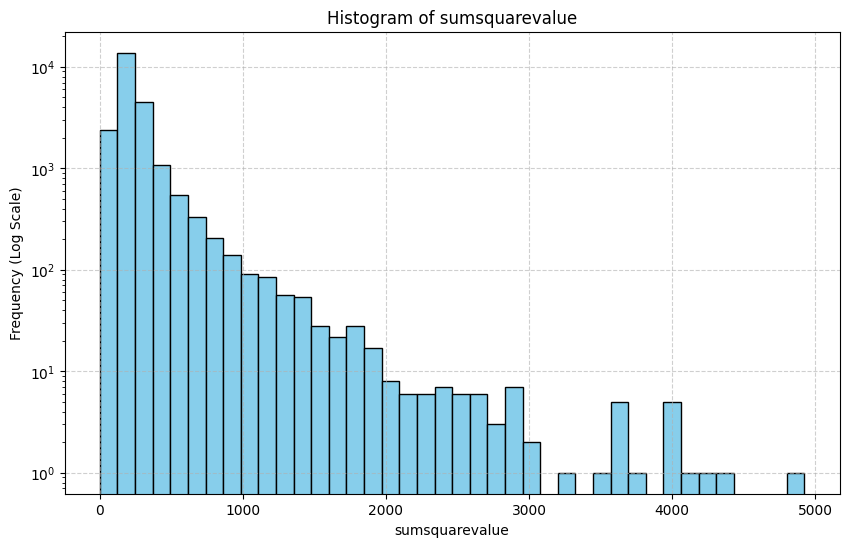

In [ ]:
fourparam_df = pd.read_csv("fourparam_table.csv")
master = pd.read_csv('Supplementary Data 1_csv.csv')


squaredata = fourparam_df['sumsquarevalue'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(squaredata, bins=40, color='skyblue', edgecolor='black')
plt.title('Histogram of sumsquarevalue')
plt.xlabel('sumsquarevalue')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [29]:

print(high_avg_cols)

['w1_Y110A7A.10.1', 'w2_F27C8.1.2', 'w3_F07C3.7.1', 'w4_F52H2.2a.1', 'w5_F52H2.2b.1', 'w6_T13A10.10a.1', 'w7_C55C2.5a.1', 'w8_T11F9.4a.1', 'w9_T11F9.4b.1', 'w10_F54D12.3.1', 'w11_F28F9.4.1', 'w12_Y53H1C.1a.2', 'w13_Y53H1C.1b.1', 'w14_C50F2.9.1', 'w15_C50F2.10.1', 'w16_Y38H6C.22.1', 'w17_T22H6.5.2', 'w18_T22H6.7.1', 'w19_M79.1a.1', 'w20_M79.1a.2', 'w21_M79.1b.1', 'w22_M79.1e.1', 'w23_C24F3.5a.1', 'w24_F12B6.1a.1', 'w25_F12B6.1b.1', 'w26_F55G11.9', 'w27_Y39D8C.1.1', 'w28_Y39D8C.1.2', 'w29_Y53C10A.9.1', 'w30_AC3.3.1', 'w31_F19G12.7.1', 'w32_Y5H2A.3.1', 'w33_C03A7.7.1', 'w34_C03A7.8.1', 'w35_C03A7.14.1', 'w36_C03A7.14.2', 'w37_F35A5.3.1', 'w38_T01D1.6.1', 'w39_W09B12.1.1', 'w40_W09B12.1.2', 'w41_Y44E3A.2.1', 'w42_Y44E3A.2.2', 'w43_Y48B6A.8.1', 'w44_Y48B6A.7.1', 'w45_C42D8.5.1', 'w46_ZK455.1.1', 'w47_ZK455.1.2', 'w48_F54H12.1a.1', 'w49_F54H12.1c.1', 'w50_F54H12.1c.2', 'w51_K11G12.2.1', 'w52_K11G12.7.1', 'w53_K03F8.2.1', 'w54_ZK973.5.1', 'w55_T09A5.3.1', 'w56_ZC504.2.1', 'w57_C40C9.2.1', 'w5